# StudyBuild — Project 02
## Customer Behavior Analysis | Full Jupyter Solution


**ترتیب کار:**
1. Data Cleaning
2. Customer Profile
3. Best City for Advertising
4. Top 10 Loyalty Customers
5. Valuable Customers at Risk
6. Discount / Device / Payment Analysis
7. Executive Report

In [6]:
# 0) Imports & Setup

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RAW_DATA = Path("First Dataset.xlsx")
CLEAN_DATA = Path("cleaned_customers.xlsx")

OUTPUT_DIR = Path("outputs")
CHART_DIR = OUTPUT_DIR / "charts"

OUTPUT_DIR.mkdir(exist_ok=True)
CHART_DIR.mkdir(exist_ok=True)

print("Project folders are ready.")

Project folders are ready.


# Part 1 — Data Cleaning

در دیتاست خام چند ایراد مشخص وجود دارد که باید قبل از تحلیل اصلاح شوند:

- یک رکورد تکراری برای `customer_id = 1014`
- یک مقدار گمشده در `age`
- یک مقدار غیرمنطقی `age = 145`
- یک مقدار گمشده در `total_spending`
- برای `customer_id = 1030` مقدار `total_spending` با رابطه‌ی `purchase_count × avg_order_value` سازگار نیست

نکته: از حذف سراسری (`dropna()` روی کل دیتاست) استفاده نمی‌کنیم، چون باعث از دست رفتن غیرضروری داده می‌شود.

In [7]:
# 1.1 Load raw data

df_raw = pd.read_excel(RAW_DATA)

print("Raw shape:", df_raw.shape)
display(df_raw.head())

Raw shape: (61, 17)


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19.0,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53.0,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31.0,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58.0,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28.0,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [8]:
# 1.2 Initial audit

print("Columns:")
print(df_raw.columns.tolist())

print("\nMissing values:")
display(df_raw.isna().sum().to_frame("missing_count"))

print("\nDuplicate full rows:", df_raw.duplicated().sum())
print("Duplicate customer IDs:", df_raw["customer_id"].duplicated().sum())

print("\nDuplicate customer IDs:")
display(
    df_raw[df_raw["customer_id"].duplicated(keep=False)]
    .sort_values("customer_id")
)

Columns:
['customer_id', 'first_name', 'gender', 'age', 'city', 'province', 'signup_date', 'membership_tier', 'purchase_count', 'avg_order_value', 'total_spending', 'last_purchase_days', 'payment_method', 'device', 'discount_used', 'returned_items', 'satisfaction_score']

Missing values:


,missing_count
customer_id,0
first_name,0
gender,0
age,1
city,0
province,0
signup_date,0
membership_tier,0
purchase_count,0
avg_order_value,0



Duplicate full rows: 1
Duplicate customer IDs: 1

Duplicate customer IDs:


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
13,1014,Reza,M,35.0,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,3353.89,97,Card,Android,No,5,4
60,1014,Reza,M,35.0,Tabriz,East Azerbaijan,2022-08-26,VIP,31,108.19,3353.89,97,Card,Android,No,5,4


In [9]:
# 1.3 Create a cleaning copy

df = df_raw.copy()

# Standardize column names
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_")
)

# Standardize text columns
text_cols = [
    "first_name", "gender", "city", "province",
    "membership_tier", "payment_method",
    "device", "discount_used"
]

for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

# Convert date
df["signup_date"] = pd.to_datetime(df["signup_date"], errors="coerce")

print("Basic standardization completed.")

Basic standardization completed.


In [10]:
# 1.4 Remove exact duplicate rows

before = len(df)

df = df.drop_duplicates().copy()

after = len(df)

print("Rows removed:", before - after)
print("Shape after removing duplicates:", df.shape)

Rows removed: 1
Shape after removing duplicates: (60, 17)


In [11]:
# 1.5 Validate numeric columns

numeric_cols = [
    "age",
    "purchase_count",
    "avg_order_value",
    "total_spending",
    "last_purchase_days",
    "returned_items",
    "satisfaction_score"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

display(df[numeric_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,59.0,45.372881,19.284529,19.00,31.5000,45.000,58.0000,145.00
purchase_count,60.0,17.383333,10.149880,0.00,10.7500,17.000,24.5000,35.00
avg_order_value,60.0,213.156500,130.509923,27.63,108.1375,165.435,324.1075,449.81
total_spending,59.0,3756.375424,4298.515563,0.00,1165.3300,2140.380,4769.2500,25000.00
last_purchase_days,60.0,198.600000,97.843043,3.00,134.2500,203.000,273.7500,365.00
returned_items,60.0,4.183333,2.683861,0.00,2.0000,4.000,7.0000,8.00
satisfaction_score,60.0,2.983333,1.431979,1.00,2.0000,3.000,4.0000,5.00


## Age Cleaning

برای پروژه‌ی حاضر، سن خارج از بازه‌ی منطقی **18 تا 100 سال** به‌عنوان مقدار نامعتبر در نظر گرفته می‌شود.

در نتیجه `145` ابتدا به Missing تبدیل می‌شود و سپس مقادیر Missing سن با **Median سن‌های معتبر** جایگزین می‌شوند. Median نسبت به Mean در برابر Outlier مقاوم‌تر است.

In [12]:
# 1.6 Clean age

invalid_age = (df["age"] < 18) | (df["age"] > 100)

print("Invalid ages before cleaning:")
display(df.loc[invalid_age, ["customer_id", "first_name", "age"]])

# Invalid ages -> NaN
df.loc[invalid_age, "age"] = np.nan

# Median imputation
age_median = df["age"].median()

print("Valid-age median:", age_median)

df["age"] = df["age"].fillna(age_median)

# Keep age as integer
df["age"] = df["age"].round().astype(int)

print("Missing ages after cleaning:", df["age"].isna().sum())

Invalid ages before cleaning:


,customer_id,first_name,age
9,1010,Arash,145.0


Valid-age median: 45.0
Missing ages after cleaning: 0


## Total Spending Validation

در این دیتاست تقریباً تمام رکوردها از رابطه‌ی زیر پیروی می‌کنند:

`total_spending = purchase_count × avg_order_value`

پس از این رابطه فقط برای **اعتبارسنجی و اصلاح رکوردهای ناسازگار/گمشده** استفاده می‌کنیم.

In [13]:
# 1.7 Validate total_spending

df["expected_total_spending"] = (
    df["purchase_count"] * df["avg_order_value"]
).round(2)

spending_issue = (
    df["total_spending"].isna()
    |
    ~np.isclose(
        df["total_spending"].fillna(-999999),
        df["expected_total_spending"],
        atol=0.02
    )
)

print("Rows requiring total_spending correction:")
display(
    df.loc[
        spending_issue,
        [
            "customer_id",
            "purchase_count",
            "avg_order_value",
            "total_spending",
            "expected_total_spending"
        ]
    ]
)

Rows requiring total_spending correction:


,customer_id,purchase_count,avg_order_value,total_spending,expected_total_spending
29,1030,26,156.89,25000.0,4079.14
39,1040,34,37.66,NaN,1280.44


In [14]:
# 1.8 Correct missing / inconsistent total_spending

df.loc[spending_issue, "total_spending"] = (
    df.loc[spending_issue, "expected_total_spending"]
)

# Remove helper column after validation
df = df.drop(columns="expected_total_spending")

print("Missing total_spending after cleaning:", df["total_spending"].isna().sum())

Missing total_spending after cleaning: 0


In [15]:
# 1.9 Business-rule validation

checks = {
    "customer_id_unique": df["customer_id"].is_unique,
    "age_18_to_100": df["age"].between(18, 100).all(),
    "purchase_count_nonnegative": (df["purchase_count"] >= 0).all(),
    "avg_order_value_nonnegative": (df["avg_order_value"] >= 0).all(),
    "total_spending_nonnegative": (df["total_spending"] >= 0).all(),
    "last_purchase_days_nonnegative": (df["last_purchase_days"] >= 0).all(),
    "returned_items_nonnegative": (df["returned_items"] >= 0).all(),
    "satisfaction_1_to_5": df["satisfaction_score"].between(1, 5).all(),
    "gender_valid": df["gender"].isin(["M", "F"]).all(),
    "discount_valid": df["discount_used"].isin(["Yes", "No"]).all(),
}

display(pd.Series(checks, name="passed"))

assert all(checks.values()), "At least one cleaning validation failed."

print("All cleaning checks passed.")

customer_id_unique                True
age_18_to_100                     True
purchase_count_nonnegative        True
avg_order_value_nonnegative       True
total_spending_nonnegative        True
last_purchase_days_nonnegative    True
returned_items_nonnegative        True
satisfaction_1_to_5               True
gender_valid                      True
discount_valid                    True
Name: passed, dtype: bool

All cleaning checks passed.


In [16]:
# 1.10 Final missing-value check

missing_after = df.isna().sum().sort_values(ascending=False)

display(missing_after.to_frame("missing_after_cleaning"))

print("Clean shape:", df.shape)
display(df.head())

,missing_after_cleaning
customer_id,0
first_name,0
gender,0
age,0
city,0
province,0
signup_date,0
membership_tier,0
purchase_count,0
avg_order_value,0


Clean shape: (60, 17)


,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score
0,1001,Reza,F,19,Karaj,Alborz,2025-02-19,VIP,17,121.53,2066.01,16,Card,Android,Yes,3,5
1,1002,Sina,M,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3
2,1003,Parsa,F,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,iPhone,Yes,6,1
3,1004,Sina,F,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4
4,1005,Kimia,M,28,Isfahan,Isfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4


In [17]:
# 1.11 Save cleaned dataset

df.to_excel(CLEAN_DATA, index=False)

print(f"Cleaned dataset saved as: {CLEAN_DATA}")

Cleaned dataset saved as: cleaned_customers.xlsx


# Part 2 — Question 1
## Core Customer Profile

بررسی می‌کنیم مشتریان اصلی از نظر:
- گروه سنی
- جنسیت
- Membership Tier
- Device
- Payment Method

در پایان یک **Dominant Persona** و یک **Marketing Implication** ارائه می‌شود.

In [18]:
# 2.1 Age groups

age_bins = [17, 24, 34, 44, 54, 64, np.inf]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels
)

profile_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Average Age",
        "Median Age",
        "Dominant Age Group",
        "Dominant Gender",
        "Dominant Membership Tier",
        "Dominant Device",
        "Dominant Payment Method"
    ],
    "Value": [
        df["customer_id"].nunique(),
        round(df["age"].mean(), 2),
        round(df["age"].median(), 2),
        df["age_group"].mode()[0],
        df["gender"].mode()[0],
        df["membership_tier"].mode()[0],
        df["device"].mode()[0],
        df["payment_method"].mode()[0]
    ]
})

display(profile_summary)

,Metric,Value
0,Total Customers,60
1,Average Age,43.7
2,Median Age,45.0
3,Dominant Age Group,55-64
4,Dominant Gender,F
5,Dominant Membership Tier,Gold
6,Dominant Device,Android
7,Dominant Payment Method,Online Wallet


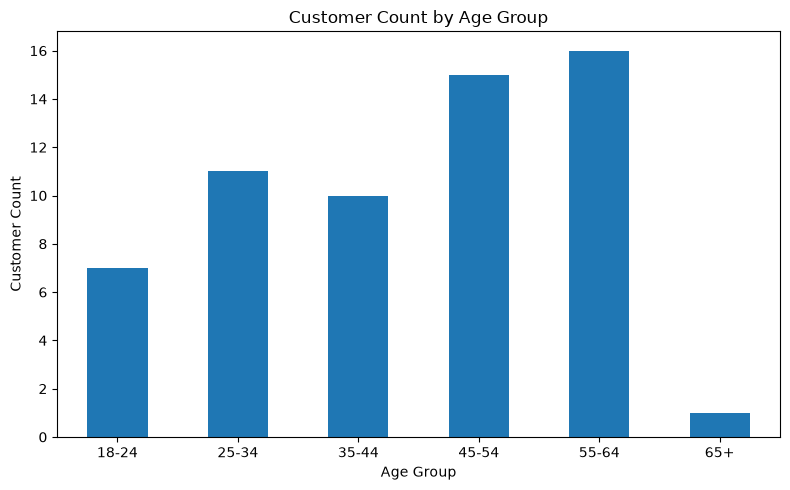

In [19]:
# 2.2 Required chart — Customer Count by Age Group

age_counts = df["age_group"].value_counts().sort_index()

plt.figure(figsize=(8,5))
age_counts.plot(kind="bar")
plt.title("Customer Count by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHART_DIR / "q1_age_group.png", dpi=300)
plt.show()

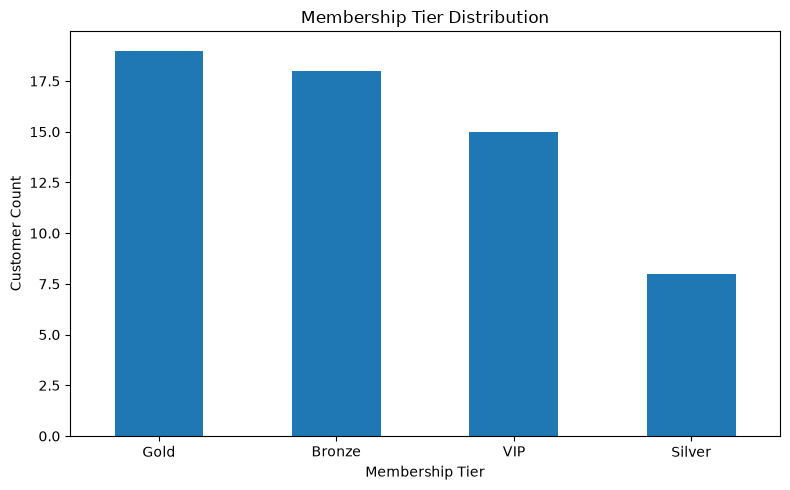

In [20]:
# 2.3 Required chart — Membership Distribution

membership_counts = df["membership_tier"].value_counts()

plt.figure(figsize=(8,5))
membership_counts.plot(kind="bar")
plt.title("Membership Tier Distribution")
plt.xlabel("Membership Tier")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHART_DIR / "q1_membership.png", dpi=300)
plt.show()

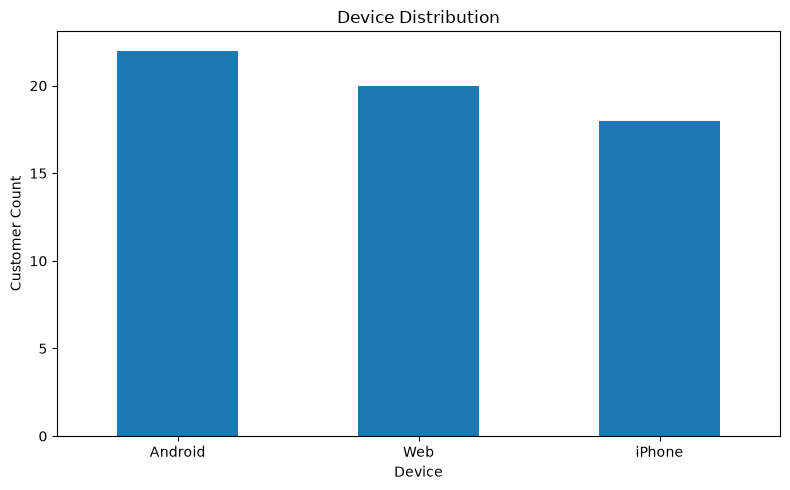

In [21]:
# 2.4 Required chart — Device Distribution

device_counts = df["device"].value_counts()

plt.figure(figsize=(8,5))
device_counts.plot(kind="bar")
plt.title("Device Distribution")
plt.xlabel("Device")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHART_DIR / "q1_device.png", dpi=300)
plt.show()

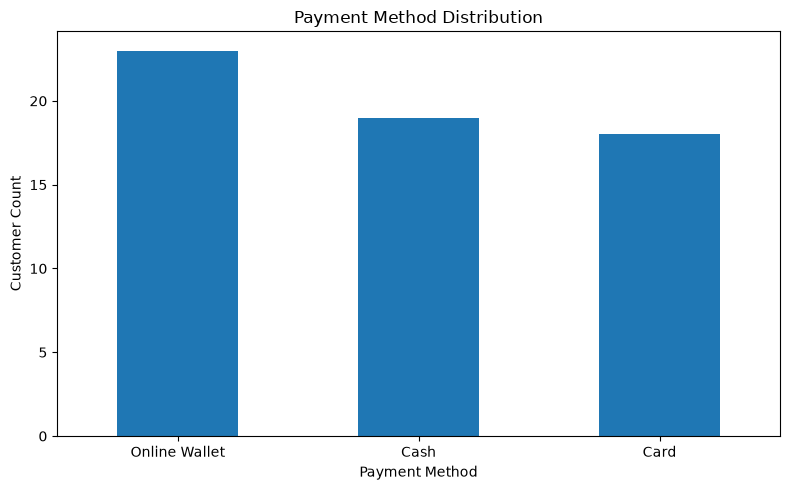

In [22]:
# 2.5 Required chart — Payment Method Distribution

payment_counts = df["payment_method"].value_counts()

plt.figure(figsize=(8,5))
payment_counts.plot(kind="bar")
plt.title("Payment Method Distribution")
plt.xlabel("Payment Method")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(CHART_DIR / "q1_payment.png", dpi=300)
plt.show()

In [23]:
# 2.6 Dominant Persona + Marketing Implication

persona = {
    "age_group": str(df["age_group"].mode()[0]),
    "gender": df["gender"].mode()[0],
    "membership": df["membership_tier"].mode()[0],
    "device": df["device"].mode()[0],
    "payment": df["payment_method"].mode()[0]
}

print("Dominant Customer Persona")
print(persona)

print(
    "\nMarketing implication:\n"
    "The dominant profile can be used as the starting point for campaign design, "
    "channel optimization and messaging. However, it should not be treated as "
    "representative of every customer segment."
)

Dominant Customer Persona
{'age_group': '55-64', 'gender': 'F', 'membership': 'Gold', 'device': 'Android', 'payment': 'Online Wallet'}

Marketing implication:
The dominant profile can be used as the starting point for campaign design, channel optimization and messaging. However, it should not be treated as representative of every customer segment.


# Part 3 — Question 2
## Best City / Province for Advertising

برای هر ترکیب `province + city` این شاخص‌ها را محاسبه می‌کنیم:

- Customer Count
- Total Revenue
- Average Customer Spending
- Average Purchase Count
- Average Order Value
- Average Satisfaction

سپس **شهر اصلی** و **شهر جایگزین** پیشنهاد می‌شوند.

In [24]:
# 3.1 City-level summary

city_summary = (
    df.groupby(["province", "city"], as_index=False)
      .agg(
          customer_count=("customer_id", "nunique"),
          total_revenue=("total_spending", "sum"),
          avg_customer_spending=("total_spending", "mean"),
          avg_purchase_count=("purchase_count", "mean"),
          avg_order_value=("avg_order_value", "mean"),
          avg_satisfaction=("satisfaction_score", "mean")
      )
      .sort_values("total_revenue", ascending=False)
      .reset_index(drop=True)
)

display(city_summary)

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
0,Khorasan,Mashhad,11,43197.58,3927.052727,22.636364,210.508182,2.909091
1,East Azerbaijan,Tabriz,12,36192.49,3016.040833,15.750000,238.901667,3.000000
2,Alborz,Karaj,7,26189.81,3741.401429,16.000000,211.440000,2.857143
3,Khuzestan,Ahvaz,8,23384.78,2923.097500,13.875000,216.531250,3.500000
4,Isfahan,Isfahan,5,21975.32,4395.064000,19.800000,212.680000,4.400000
5,Fars,Shiraz,6,20715.92,3452.653333,16.333333,180.983333,2.000000
6,Gilan,Rasht,5,15168.54,3033.708000,16.400000,241.554000,2.600000
7,Tehran,Tehran,6,15161.29,2526.881667,17.166667,172.930000,2.666667


In [25]:
# 3.2 Primary + Alternative City

primary_city = city_summary.iloc[0]

alternative_pool = city_summary.iloc[1:].copy()

alternative_pool["opportunity_score"] = (
    alternative_pool["avg_customer_spending"].rank(pct=True)
    + alternative_pool["avg_satisfaction"].rank(pct=True)
    + alternative_pool["customer_count"].rank(pct=True)
)

alternative_city = (
    alternative_pool
    .sort_values("opportunity_score", ascending=False)
    .iloc[0]
)

print("PRIMARY CITY")
display(primary_city.to_frame("value"))

print("\nALTERNATIVE CITY")
display(alternative_city.to_frame("value"))

print(
    "\nInterpretation: The primary city is selected from current observed revenue. "
    "The alternative city provides a useful trade-off based on customer value, "
    "satisfaction and customer-base size. This is not proof of advertising ROI."
)

PRIMARY CITY


,value
province,Khorasan
city,Mashhad
customer_count,11
total_revenue,43197.58
avg_customer_spending,3927.052727
avg_purchase_count,22.636364
avg_order_value,210.508182
avg_satisfaction,2.909091



ALTERNATIVE CITY


,value
province,Isfahan
city,Isfahan
customer_count,5
total_revenue,21975.32
avg_customer_spending,4395.064
avg_purchase_count,19.8
avg_order_value,212.68
avg_satisfaction,4.4
opportunity_score,2.214286



Interpretation: The primary city is selected from current observed revenue. The alternative city provides a useful trade-off based on customer value, satisfaction and customer-base size. This is not proof of advertising ROI.


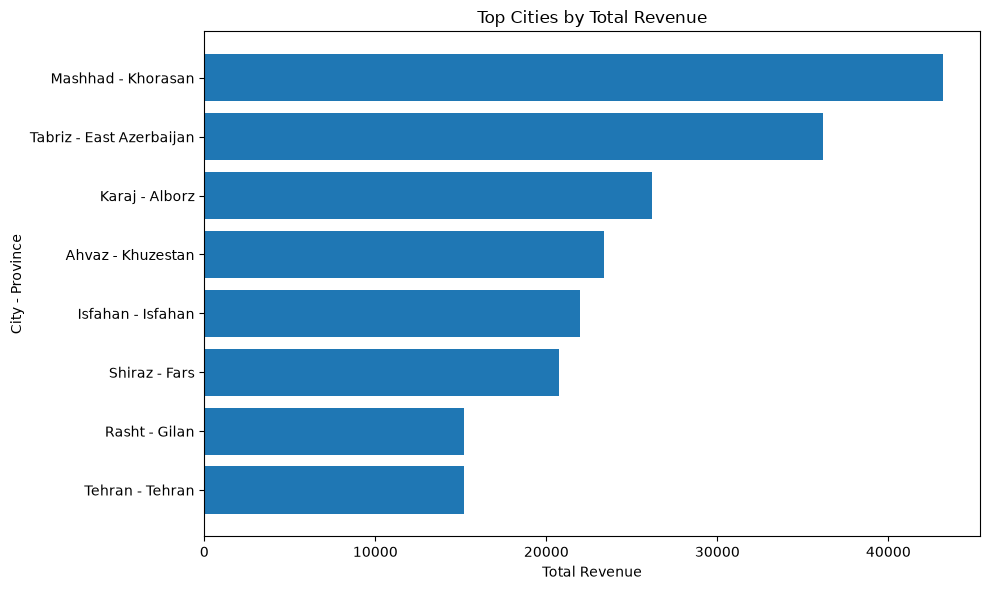

In [26]:
# 3.3 Required chart — Top Cities by Revenue

top_cities = city_summary.nlargest(10, "total_revenue").sort_values("total_revenue")
labels = top_cities["city"] + " - " + top_cities["province"]

plt.figure(figsize=(10,6))
plt.barh(labels, top_cities["total_revenue"])
plt.title("Top Cities by Total Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("City - Province")
plt.tight_layout()
plt.savefig(CHART_DIR / "q2_top_cities_revenue.png", dpi=300)
plt.show()

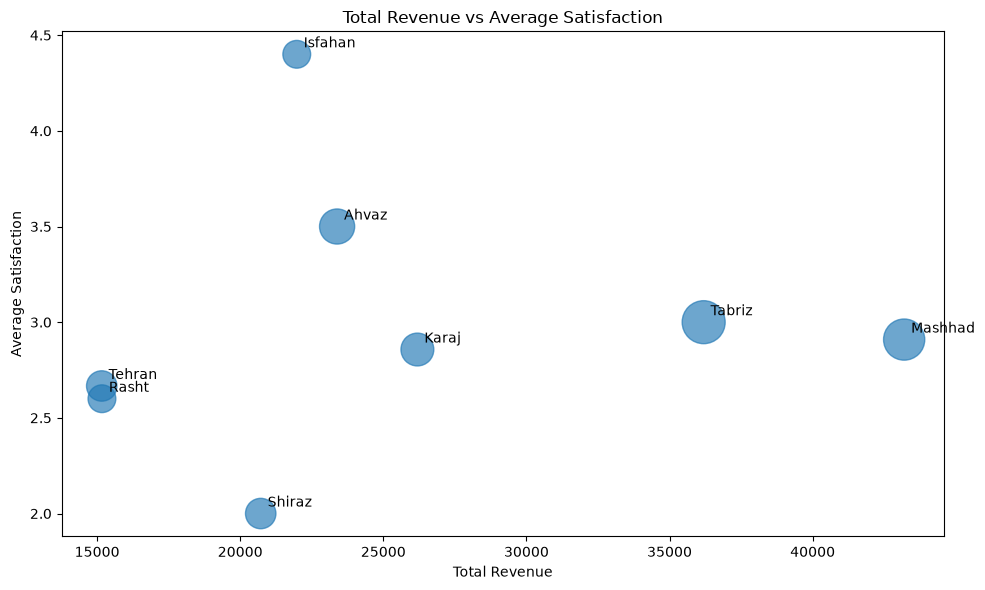

In [27]:
# 3.4 Required bubble chart
# X = Total Revenue
# Y = Average Satisfaction
# Bubble Size = Customer Count

plt.figure(figsize=(10,6))

plt.scatter(
    city_summary["total_revenue"],
    city_summary["avg_satisfaction"],
    s=city_summary["customer_count"] * 80,
    alpha=0.65
)

for _, row in city_summary.iterrows():
    plt.annotate(
        row["city"],
        (row["total_revenue"], row["avg_satisfaction"]),
        xytext=(5,5),
        textcoords="offset points"
    )

plt.title("Total Revenue vs Average Satisfaction")
plt.xlabel("Total Revenue")
plt.ylabel("Average Satisfaction")
plt.tight_layout()
plt.savefig(CHART_DIR / "q2_revenue_satisfaction.png", dpi=300)
plt.show()

# Part 4 — Question 3
## Top 10 Loyalty Customers

Loyalty Score فقط از رفتار واقعی مشتری ساخته می‌شود:

- 35% Total Spending
- 30% Purchase Frequency
- 20% Recency
- 15% Satisfaction

**Membership Tier داخل Score قرار نمی‌گیرد** و فقط بعد از رتبه‌بندی مقایسه می‌شود.

In [28]:
# 4.1 Min-Max normalization

def minmax(series):
    smin = series.min()
    smax = series.max()
    if smax == smin:
        return pd.Series(1.0, index=series.index)
    return (series - smin) / (smax - smin)

loyalty = df.copy()

loyalty["spending_score"] = minmax(loyalty["total_spending"])
loyalty["frequency_score"] = minmax(loyalty["purchase_count"])

# Lower days = more recent = better
loyalty["recency_score"] = 1 - minmax(loyalty["last_purchase_days"])

loyalty["satisfaction_norm"] = minmax(loyalty["satisfaction_score"])

loyalty["loyalty_score"] = (
    0.35 * loyalty["spending_score"]
    + 0.30 * loyalty["frequency_score"]
    + 0.20 * loyalty["recency_score"]
    + 0.15 * loyalty["satisfaction_norm"]
)

top10 = (
    loyalty
    .sort_values("loyalty_score", ascending=False)
    .head(10)
    .copy()
)

top10["rank"] = range(1, 11)

display(
    top10[
        [
            "rank", "customer_id", "first_name", "membership_tier",
            "total_spending", "purchase_count", "last_purchase_days",
            "satisfaction_score", "loyalty_score"
        ]
    ]
)

,rank,customer_id,first_name,membership_tier,total_spending,purchase_count,last_purchase_days,satisfaction_score,loyalty_score
56,1,1057,Maryam,Bronze,13532.74,31,82,4,0.864535
43,2,1044,Mina,Gold,14354.34,33,165,2,0.780854
58,3,1059,Ali,Gold,8898.55,31,224,5,0.710587
8,4,1009,Kimia,Silver,11615.42,34,232,2,0.685627
3,5,1004,Sina,Gold,6121.45,23,40,4,0.638459
11,6,1012,Arash,Gold,11731.50,27,224,2,0.632877
32,7,1033,Neda,VIP,5521.20,24,112,5,0.630116
13,8,1014,Reza,VIP,3353.89,31,97,4,0.608058
22,9,1023,Ali,Bronze,3851.44,31,170,4,0.579858
16,10,1017,Parsa,VIP,3239.40,30,135,4,0.575701


In [29]:
# 4.2 Evidence-based reason for EACH selected customer

spend_med = loyalty["total_spending"].median()
freq_med = loyalty["purchase_count"].median()
recency_med = loyalty["last_purchase_days"].median()
sat_med = loyalty["satisfaction_score"].median()

def loyalty_reason(row):
    reasons = []

    if row["total_spending"] >= spend_med:
        reasons.append("high spending")
    if row["purchase_count"] >= freq_med:
        reasons.append("high purchase frequency")
    if row["last_purchase_days"] <= recency_med:
        reasons.append("recent activity")
    if row["satisfaction_score"] >= sat_med:
        reasons.append("good satisfaction")

    return ", ".join(reasons) if reasons else "strong combined loyalty score"

top10["reason"] = top10.apply(loyalty_reason, axis=1)

top10_table = top10[
    [
        "rank", "customer_id", "first_name", "membership_tier",
        "total_spending", "purchase_count", "last_purchase_days",
        "satisfaction_score", "loyalty_score", "reason"
    ]
]

display(top10_table)

,rank,customer_id,first_name,membership_tier,total_spending,purchase_count,last_purchase_days,satisfaction_score,loyalty_score,reason
56,1,1057,Maryam,Bronze,13532.74,31,82,4,0.864535,"high spending, high purchase frequency, recent..."
43,2,1044,Mina,Gold,14354.34,33,165,2,0.780854,"high spending, high purchase frequency, recent..."
58,3,1059,Ali,Gold,8898.55,31,224,5,0.710587,"high spending, high purchase frequency, good s..."
8,4,1009,Kimia,Silver,11615.42,34,232,2,0.685627,"high spending, high purchase frequency"
3,5,1004,Sina,Gold,6121.45,23,40,4,0.638459,"high spending, high purchase frequency, recent..."
11,6,1012,Arash,Gold,11731.50,27,224,2,0.632877,"high spending, high purchase frequency"
32,7,1033,Neda,VIP,5521.20,24,112,5,0.630116,"high spending, high purchase frequency, recent..."
13,8,1014,Reza,VIP,3353.89,31,97,4,0.608058,"high spending, high purchase frequency, recent..."
22,9,1023,Ali,Bronze,3851.44,31,170,4,0.579858,"high spending, high purchase frequency, recent..."
16,10,1017,Parsa,VIP,3239.40,30,135,4,0.575701,"high spending, high purchase frequency, recent..."


In [30]:
# 4.3 Compare Membership Tier AFTER scoring

membership_top10 = (
    top10["membership_tier"]
    .value_counts()
    .rename_axis("membership_tier")
    .reset_index(name="top10_customer_count")
)

display(membership_top10)

,membership_tier,top10_customer_count
0,Gold,4
1,VIP,3
2,Bronze,2
3,Silver,1


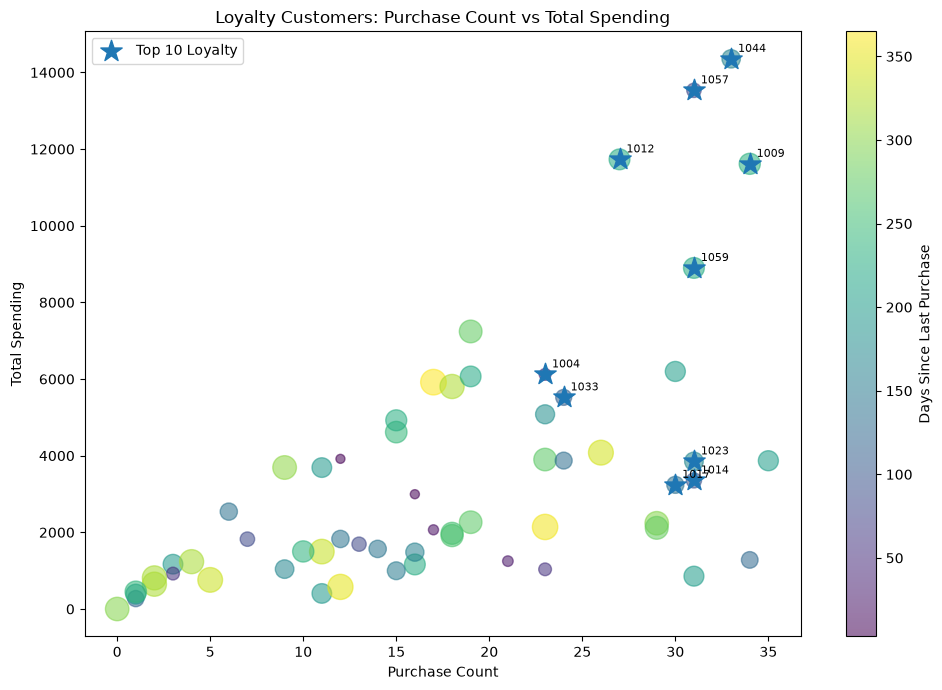

In [31]:
# 4.4 Required Loyalty Scatter
# X = Purchase Count
# Y = Total Spending
# Recency = Size + Color
# Top 10 = Highlighted

point_sizes = (
    loyalty["last_purchase_days"].clip(lower=1)
    / loyalty["last_purchase_days"].max()
) * 300 + 40

plt.figure(figsize=(10,7))

sc = plt.scatter(
    loyalty["purchase_count"],
    loyalty["total_spending"],
    s=point_sizes,
    c=loyalty["last_purchase_days"],
    alpha=0.55
)

plt.colorbar(sc, label="Days Since Last Purchase")

plt.scatter(
    top10["purchase_count"],
    top10["total_spending"],
    marker="*",
    s=260,
    label="Top 10 Loyalty"
)

for _, row in top10.iterrows():
    plt.annotate(
        str(row["customer_id"]),
        (row["purchase_count"], row["total_spending"]),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Loyalty Customers: Purchase Count vs Total Spending")
plt.xlabel("Purchase Count")
plt.ylabel("Total Spending")
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "q3_loyalty_scatter.png", dpi=300)
plt.show()

# Part 5 — Question 4
## Valuable Customers at Risk

یک مشتری فقط زمانی At-Risk در نظر گرفته می‌شود که **هر سه شرط** را داشته باشد:

1. High Spending
2. High Purchase Frequency
3. Long Inactivity

این افراد **Confirmed Churners نیستند**؛ فقط دارای نشانه‌ی inactivity risk هستند.

In [32]:
# 5.1 Thresholds

spending_threshold = df["total_spending"].quantile(0.75)
frequency_threshold = df["purchase_count"].median()
inactivity_threshold = df["last_purchase_days"].quantile(0.75)

print("Spending threshold (Q75):", round(spending_threshold, 2))
print("Purchase-count threshold (Median):", frequency_threshold)
print("Inactivity threshold (Q75):", inactivity_threshold)

Spending threshold (Q75): 4213.12
Purchase-count threshold (Median): 17.0
Inactivity threshold (Q75): 273.75


In [33]:
# 5.2 At-Risk rule

risk = df.copy()

risk["at_risk"] = (
    (risk["total_spending"] >= spending_threshold)
    &
    (risk["purchase_count"] >= frequency_threshold)
    &
    (risk["last_purchase_days"] >= inactivity_threshold)
)

at_risk = risk[risk["at_risk"]].copy()

print("Number of high-value customers at risk:", len(at_risk))

display(
    at_risk[
        [
            "customer_id", "first_name", "total_spending",
            "purchase_count", "last_purchase_days",
            "satisfaction_score"
        ]
    ]
)

Number of high-value customers at risk: 3


,customer_id,first_name,total_spending,purchase_count,last_purchase_days,satisfaction_score
9,1010,Arash,7241.47,19,276,1
34,1035,Arash,5918.21,17,365,3
52,1053,Sina,5805.54,18,320,1


In [34]:
# 5.3 Different action based on Satisfaction

satisfaction_cutoff = df["satisfaction_score"].median()

def retention_action(row):
    if row["satisfaction_score"] < satisfaction_cutoff:
        return "Service recovery + feedback call before incentive"
    return "Personalized win-back offer + reminder campaign"

at_risk["recommended_action"] = at_risk.apply(retention_action, axis=1)

display(
    at_risk[
        [
            "customer_id", "first_name", "total_spending",
            "purchase_count", "last_purchase_days",
            "satisfaction_score", "recommended_action"
        ]
    ]
)

,customer_id,first_name,total_spending,purchase_count,last_purchase_days,satisfaction_score,recommended_action
9,1010,Arash,7241.47,19,276,1,Service recovery + feedback call before incentive
34,1035,Arash,5918.21,17,365,3,Personalized win-back offer + reminder campaign
52,1053,Sina,5805.54,18,320,1,Service recovery + feedback call before incentive


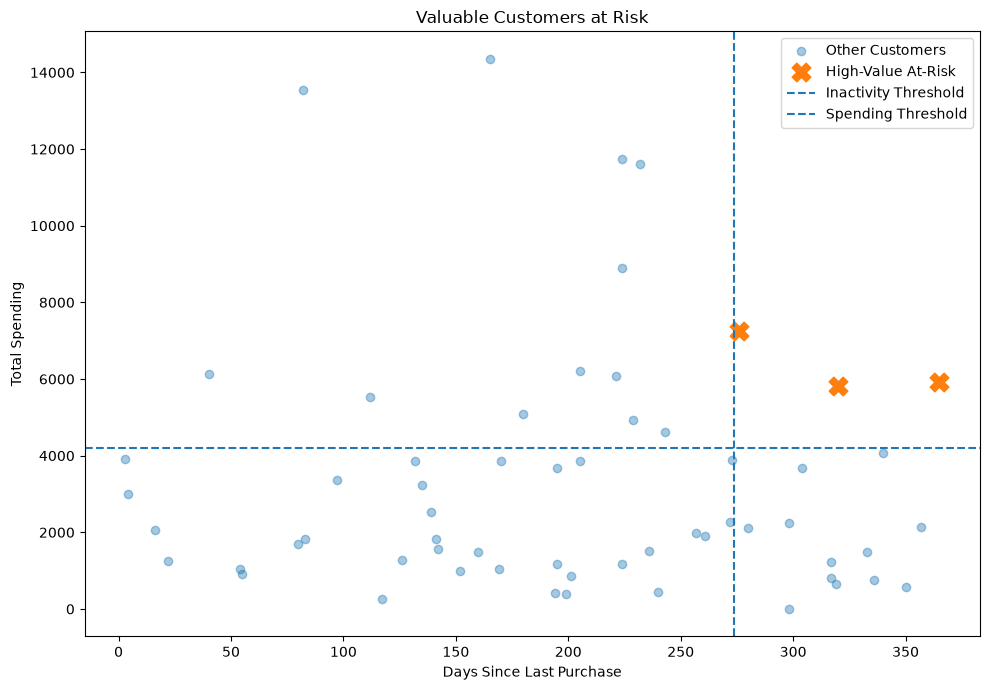

In [35]:
# 5.4 Required At-Risk Scatter

plt.figure(figsize=(10,7))

plt.scatter(
    risk.loc[~risk["at_risk"], "last_purchase_days"],
    risk.loc[~risk["at_risk"], "total_spending"],
    alpha=0.4,
    label="Other Customers"
)

plt.scatter(
    at_risk["last_purchase_days"],
    at_risk["total_spending"],
    marker="X",
    s=180,
    label="High-Value At-Risk"
)

plt.axvline(
    inactivity_threshold,
    linestyle="--",
    label="Inactivity Threshold"
)

plt.axhline(
    spending_threshold,
    linestyle="--",
    label="Spending Threshold"
)

plt.title("Valuable Customers at Risk")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Total Spending")
plt.legend()
plt.tight_layout()
plt.savefig(CHART_DIR / "q4_at_risk.png", dpi=300)
plt.show()

# Part 6 — Question 5
## Discount, Device & Payment

Discount Users و Non-Discount Users را روی این شاخص‌ها مقایسه می‌کنیم:

- Average Total Spending
- Average Purchase Count
- Average Order Value
- Average Returned Items
- Average Satisfaction

**هشدار:** `returned_items / purchase_count` را Return Rate نمی‌نامیم، چون واحد دو متغیر متفاوت است.

In [36]:
# 6.1 Discount summary

discount_summary = (
    df.groupby("discount_used", as_index=False)
      .agg(
          customer_count=("customer_id", "nunique"),
          avg_total_spending=("total_spending", "mean"),
          avg_purchase_count=("purchase_count", "mean"),
          avg_order_value=("avg_order_value", "mean"),
          avg_returned_items=("returned_items", "mean"),
          avg_satisfaction=("satisfaction_score", "mean")
      )
)

display(discount_summary)

print(
    "Interpretation: These are descriptive differences only. "
    "They do not establish a causal effect of discounts."
)

,discount_used,customer_count,avg_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
0,No,34,3736.741176,17.294118,220.700588,4.264706,2.764706
1,Yes,26,2882.174231,17.500000,203.291154,4.076923,3.269231


Interpretation: These are descriptive differences only. They do not establish a causal effect of discounts.


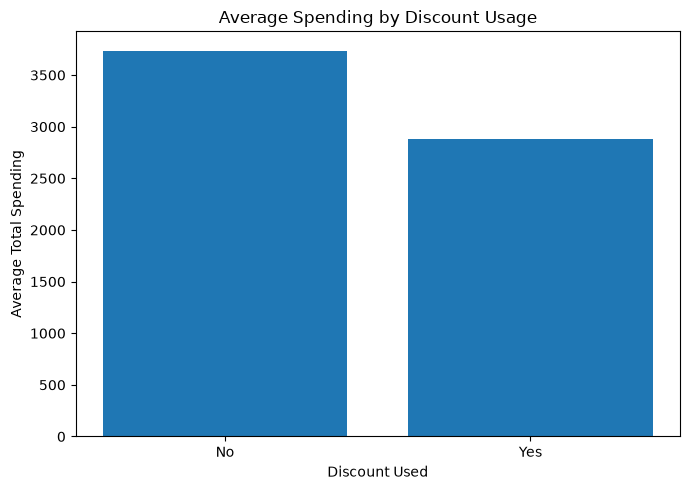

In [37]:
# 6.2 Required chart — Average Spending by Discount

plt.figure(figsize=(7,5))
plt.bar(
    discount_summary["discount_used"],
    discount_summary["avg_total_spending"]
)
plt.title("Average Spending by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Average Total Spending")
plt.tight_layout()
plt.savefig(CHART_DIR / "q5_discount_spending.png", dpi=300)
plt.show()

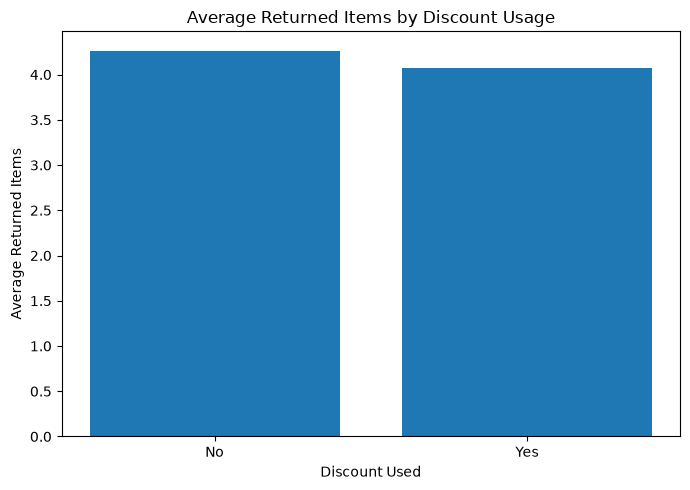

In [38]:
# 6.3 Required chart — Average Returned Items by Discount

plt.figure(figsize=(7,5))
plt.bar(
    discount_summary["discount_used"],
    discount_summary["avg_returned_items"]
)
plt.title("Average Returned Items by Discount Usage")
plt.xlabel("Discount Used")
plt.ylabel("Average Returned Items")
plt.tight_layout()
plt.savefig(CHART_DIR / "q5_discount_returns.png", dpi=300)
plt.show()

,customer_count,avg_spending
device,,
iPhone,18,3773.945000
Android,22,3459.069091
Web,20,2897.760000


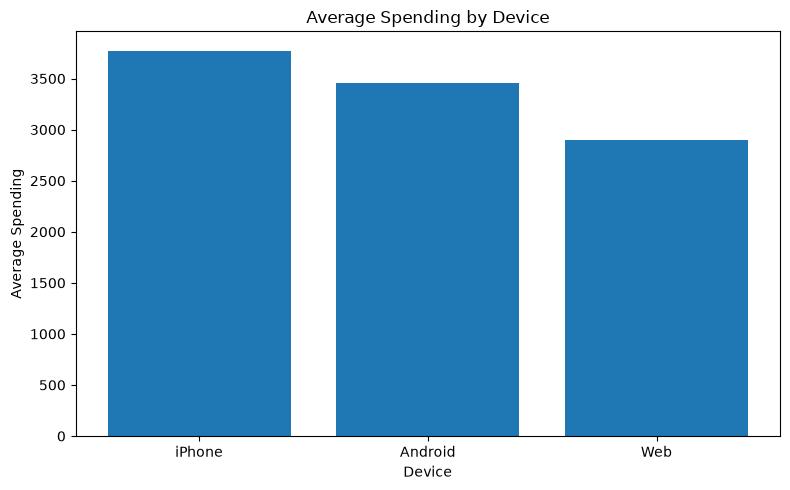

In [39]:
# 6.4 Device analysis + required chart

device_summary = (
    df.groupby("device")
      .agg(
          customer_count=("customer_id", "nunique"),
          avg_spending=("total_spending", "mean")
      )
      .sort_values("avg_spending", ascending=False)
)

display(device_summary)

plt.figure(figsize=(8,5))
plt.bar(device_summary.index, device_summary["avg_spending"])
plt.title("Average Spending by Device")
plt.xlabel("Device")
plt.ylabel("Average Spending")
plt.tight_layout()
plt.savefig(CHART_DIR / "q5_device_spending.png", dpi=300)
plt.show()

,customer_count,avg_spending
payment_method,,
Card,18,3929.005000
Cash,19,3150.579474
Online Wallet,23,3104.462174


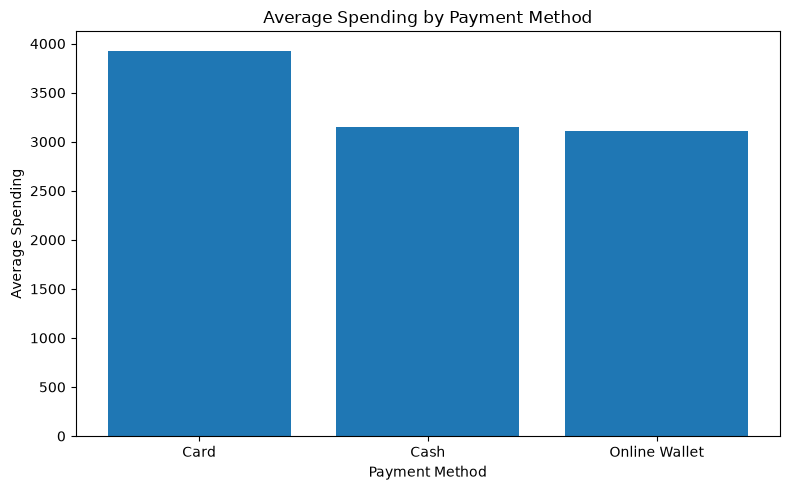

In [40]:
# 6.5 Payment analysis + required chart

payment_summary = (
    df.groupby("payment_method")
      .agg(
          customer_count=("customer_id", "nunique"),
          avg_spending=("total_spending", "mean")
      )
      .sort_values("avg_spending", ascending=False)
)

display(payment_summary)

plt.figure(figsize=(8,5))
plt.bar(payment_summary.index, payment_summary["avg_spending"])
plt.title("Average Spending by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Spending")
plt.tight_layout()
plt.savefig(CHART_DIR / "q5_payment_spending.png", dpi=300)
plt.show()

# Part 7 — Question 6
## Executive Report

خروجی CEO باید دقیقاً شامل:
- **6 KPI**
- **3 Chart**
- **3 Recommendation**

باشد.

In [41]:
# 7.1 Exactly 6 KPIs

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Customers",
        "Total Revenue",
        "Average Customer Spending",
        "Average Purchase Count",
        "Average Satisfaction",
        "High-Value At-Risk Customers"
    ],
    "Value": [
        df["customer_id"].nunique(),
        round(df["total_spending"].sum(), 2),
        round(df["total_spending"].mean(), 2),
        round(df["purchase_count"].mean(), 2),
        round(df["satisfaction_score"].mean(), 2),
        len(at_risk)
    ]
})

assert len(kpi_summary) == 6

display(kpi_summary)

,KPI,Value
0,Total Customers,60.00
1,Total Revenue,201985.73
2,Average Customer Spending,3366.43
3,Average Purchase Count,17.38
4,Average Satisfaction,2.98
5,High-Value At-Risk Customers,3.00


In [42]:
# 7.2 Exactly 3 Recommendations
# KPI -> Evidence -> Action

recommendations = pd.DataFrame({
    "Recommendation": [
        "Regional Marketing Pilot",
        "High-Value Customer Reactivation",
        "Discount Strategy Optimization"
    ],
    "KPI": [
        "Revenue from Target Region",
        "Reactivation Rate",
        "Average Spending & Returned Items"
    ],
    "Evidence": [
        f"{primary_city['city']} has the highest observed current city revenue.",
        f"{len(at_risk)} high-value and frequent customers show long inactivity.",
        "Discount and non-discount groups show different observed customer metrics."
    ],
    "Action": [
        f"Run a controlled marketing pilot in {primary_city['city']} and compare it with {alternative_city['city']}.",
        "Use service recovery for dissatisfied inactive customers and personalized win-back offers for satisfied inactive customers.",
        "Run a controlled A/B test before making causal conclusions about discount effectiveness."
    ]
})

assert len(recommendations) == 3

display(recommendations)

,Recommendation,KPI,Evidence,Action
0,Regional Marketing Pilot,Revenue from Target Region,Mashhad has the highest observed current city ...,Run a controlled marketing pilot in Mashhad an...
1,High-Value Customer Reactivation,Reactivation Rate,3 high-value and frequent customers show long ...,Use service recovery for dissatisfied inactive...
2,Discount Strategy Optimization,Average Spending & Returned Items,Discount and non-discount groups show differen...,Run a controlled A/B test before making causal...


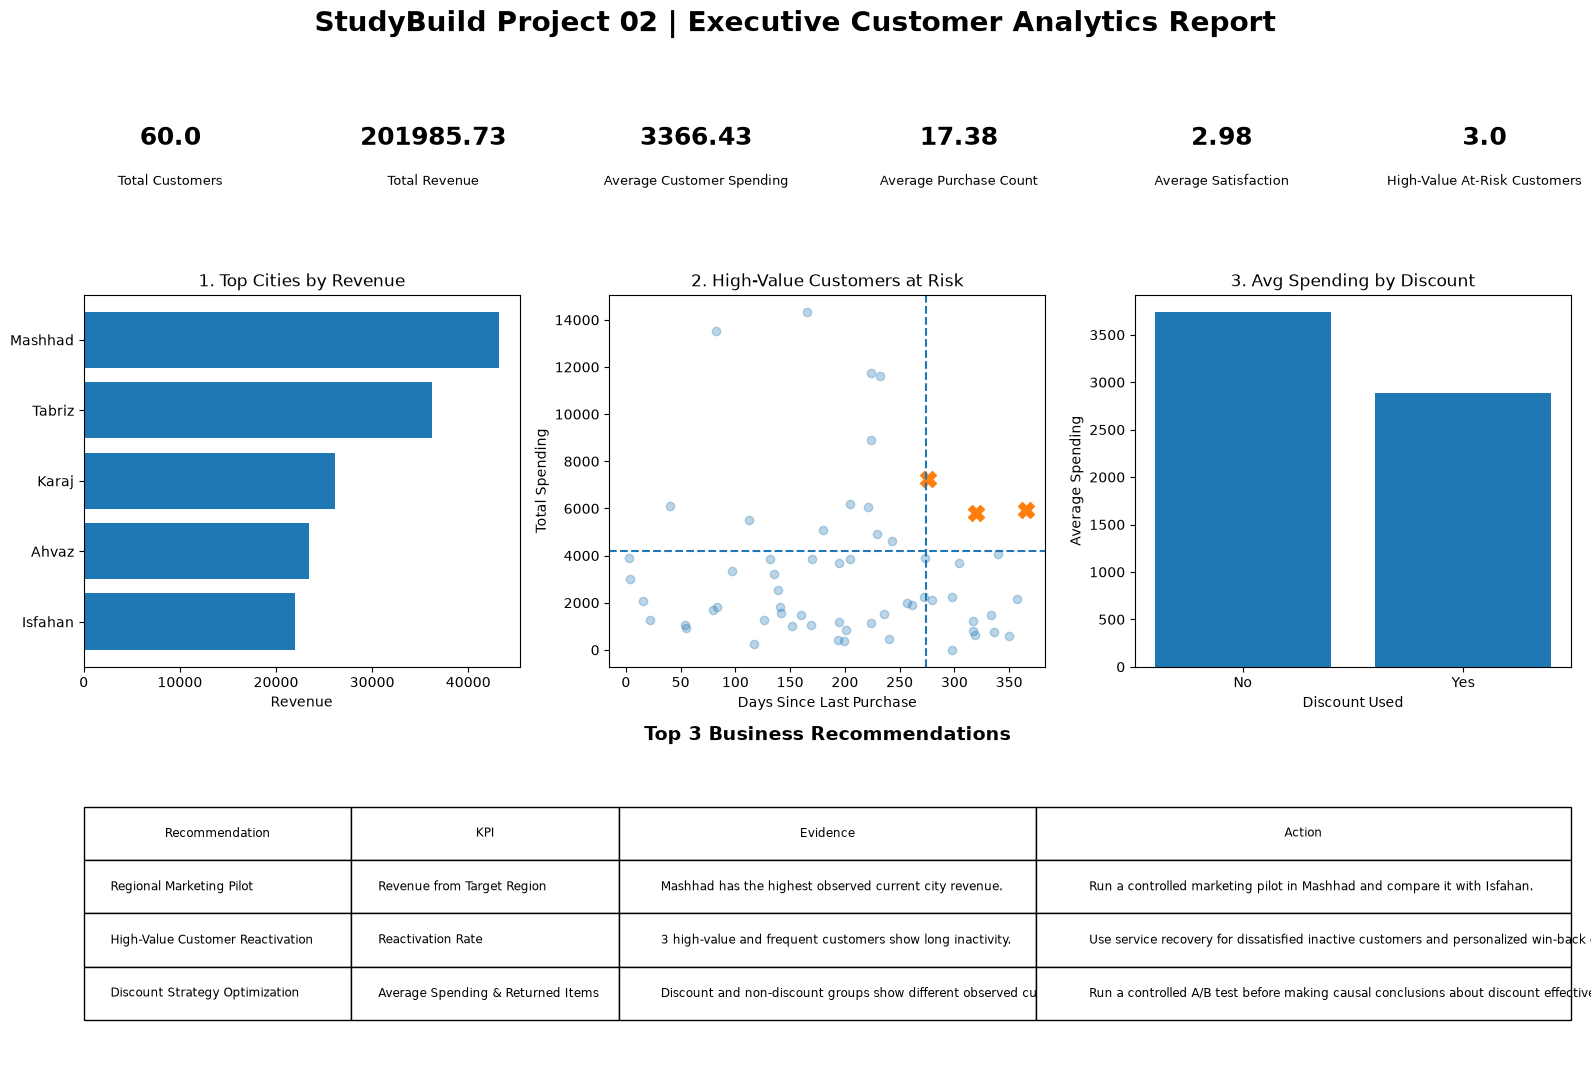

In [43]:
# 7.3 One-page Executive Report
# Exactly 3 charts are selected from previous analyses.

fig = plt.figure(figsize=(16, 11))
gs = fig.add_gridspec(3, 6, height_ratios=[1.0, 3.5, 3.0])

fig.suptitle(
    "StudyBuild Project 02 | Executive Customer Analytics Report",
    fontsize=20,
    fontweight="bold"
)

# KPI cards
for i, row in kpi_summary.iterrows():
    ax = fig.add_subplot(gs[0, i])
    ax.axis("off")
    ax.text(
        0.5, 0.65, str(row["Value"]),
        ha="center", va="center",
        fontsize=18, fontweight="bold"
    )
    ax.text(
        0.5, 0.25, row["KPI"],
        ha="center", va="center",
        fontsize=9, wrap=True
    )

# Chart 1 — Top cities revenue
ax1 = fig.add_subplot(gs[1, 0:2])
exec_city = city_summary.nlargest(5, "total_revenue").sort_values("total_revenue")
ax1.barh(exec_city["city"], exec_city["total_revenue"])
ax1.set_title("1. Top Cities by Revenue")
ax1.set_xlabel("Revenue")

# Chart 2 — At risk
ax2 = fig.add_subplot(gs[1, 2:4])
ax2.scatter(
    risk.loc[~risk["at_risk"], "last_purchase_days"],
    risk.loc[~risk["at_risk"], "total_spending"],
    alpha=0.3
)
ax2.scatter(
    at_risk["last_purchase_days"],
    at_risk["total_spending"],
    marker="X", s=130
)
ax2.axvline(inactivity_threshold, linestyle="--")
ax2.axhline(spending_threshold, linestyle="--")
ax2.set_title("2. High-Value Customers at Risk")
ax2.set_xlabel("Days Since Last Purchase")
ax2.set_ylabel("Total Spending")

# Chart 3 — Discount spending
ax3 = fig.add_subplot(gs[1, 4:6])
ax3.bar(
    discount_summary["discount_used"],
    discount_summary["avg_total_spending"]
)
ax3.set_title("3. Avg Spending by Discount")
ax3.set_xlabel("Discount Used")
ax3.set_ylabel("Average Spending")

# Recommendation table
ax_rec = fig.add_subplot(gs[2, :])
ax_rec.axis("off")

tbl = ax_rec.table(
    cellText=recommendations[
        ["Recommendation", "KPI", "Evidence", "Action"]
    ].values,
    colLabels=[
        "Recommendation", "KPI", "Evidence", "Action"
    ],
    cellLoc="left",
    loc="center",
    colWidths=[0.18, 0.18, 0.28, 0.36]
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 3.0)

ax_rec.set_title(
    "Top 3 Business Recommendations",
    fontsize=14,
    fontweight="bold",
    pad=10
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig(
    OUTPUT_DIR / "Executive_Report_One_Page.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    OUTPUT_DIR / "Executive_Report_One_Page.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
# 7.4 Export analytical tables to Excel

with pd.ExcelWriter(OUTPUT_DIR / "customer_analytics_results.xlsx") as writer:

    profile_summary.to_excel(
        writer, sheet_name="Customer Profile", index=False
    )

    city_summary.to_excel(
        writer, sheet_name="City Analysis", index=False
    )

    top10_table.to_excel(
        writer, sheet_name="Top 10 Loyalty", index=False
    )

    at_risk[
        [
            "customer_id", "first_name", "total_spending",
            "purchase_count", "last_purchase_days",
            "satisfaction_score", "recommended_action"
        ]
    ].to_excel(
        writer, sheet_name="At Risk Customers", index=False
    )

    discount_summary.to_excel(
        writer, sheet_name="Discount Analysis", index=False
    )

    device_summary.to_excel(
        writer, sheet_name="Device Analysis"
    )

    payment_summary.to_excel(
        writer, sheet_name="Payment Analysis"
    )

    kpi_summary.to_excel(
        writer, sheet_name="CEO KPIs", index=False
    )

    recommendations.to_excel(
        writer, sheet_name="Recommendations", index=False
    )

print("Analytical Excel output saved.")

Analytical Excel output saved.


In [45]:
# 7.5 Final validation

assert df["customer_id"].is_unique
assert df["age"].between(18,100).all()
assert df["total_spending"].notna().all()
assert len(top10) == 10
assert len(kpi_summary) == 6
assert len(recommendations) == 3

print("=" * 60)
print("FINAL PROJECT CHECK")
print("=" * 60)

print("Clean customers:", df["customer_id"].nunique())
print("Top Loyalty Customers:", len(top10))
print("At-Risk Customers:", len(at_risk))
print("Executive KPI Count:", len(kpi_summary))
print("Executive Recommendation Count:", len(recommendations))

print("\nAll final checks passed.")

FINAL PROJECT CHECK
Clean customers: 60
Top Loyalty Customers: 10
At-Risk Customers: 3
Executive KPI Count: 6
Executive Recommendation Count: 3

All final checks passed.


# Final Methodological Notes

- `Membership Tier` در Loyalty Score وارد نشده است.
- `returned_items / purchase_count` به‌عنوان Return Rate گزارش نشده است.
- At-Risk به معنی **inactivity risk** است، نه confirmed churn.
- تفاوت Discount Users و Non-Discount Users **توصیفی** است، نه علّی.
- از Revenue به‌عنوان Profit یاد نشده است.
- انتخاب شهر تبلیغاتی بر اساس رفتار فعلی مشتریان است و به معنی اثبات ROI تبلیغات نیست.